In [13]:
# %%
import pandas as pd
import numpy as np
import warnings
import lightgbm as lgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

warnings.filterwarnings("ignore")

In [15]:
# 한글 폰트
import matplotlib.pyplot as plt
import warnings

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

warnings.filterwarnings("ignore")

In [3]:
# 전처리 설정값
# %%
HIGH_NULL_COLS = [
    "착상 전 유전 검사 사용 여부", "PGD 시술 여부", "PGS 시술 여부",
    "난자 해동 경과일", "배아 해동 경과일",
]
COUNT_COLS = [
    "총 시술 횟수", "클리닉 내 총 시술 횟수",
    "IVF 시술 횟수", "DI 시술 횟수",
    "총 임신 횟수", "IVF 임신 횟수", "DI 임신 횟수",
    "총 출산 횟수", "IVF 출산 횟수", "DI 출산 횟수",
]
AGE_MAP = {
    "만18-34세": 26, "만35-37세": 36, "만38-39세": 38,
    "만40-42세": 41, "만43-44세": 43, "만45-50세": 47, "Unknown": 36
}
DONOR_AGE_MAP = {
    "만20세 이하": 19, "만21-25세": 23, "만26-30세": 28,
    "만31-35세": 33, "만36-40세": 38, "만41-45세": 43,
    "알 수 없음": 0, "Unknown": 0
}
CAUSE_COLS = [
    "불임 원인 - 난관 질환", "불임 원인 - 남성 요인", "불임 원인 - 배란 장애",
    "불임 원인 - 여성 요인", "불임 원인 - 자궁경부 문제", "불임 원인 - 자궁내막증",
    "불임 원인 - 정자 농도", "불임 원인 - 정자 면역학적 요인",
    "불임 원인 - 정자 운동성", "불임 원인 - 정자 형태",
]
LOG_COLS = [
    "총 생성 배아 수", "미세주입된 난자 수", "미세주입에서 생성된 배아 수",
    "저장된 배아 수", "수집된 신선 난자 수", "혼합된 난자 수",
    "파트너 정자와 혼합된 난자 수", "미세주입 배아 이식 수",
]

label_encoders = {}

In [4]:
# ════════════════════════════════════════════════════════════
# 전처리 함수
# ════════════════════════════════════════════════════════════

def convert_count(val):
    if pd.isna(val) or val == "Unknown":
        return 0
    if "이상" in str(val):
        return 6
    try:
        return int(str(val).replace("회", "").strip())
    except:
        return 0


def preprocess(df, is_train=True):
    df = df.copy()
    ids = df["ID"].copy() if "ID" in df.columns else None
    df = df.drop(columns=["ID"], errors="ignore")
    df = df.drop(columns=[c for c in HIGH_NULL_COLS if c in df.columns])

    date_cols = [c for c in ["난자 채취 경과일", "난자 혼합 경과일", "배아 이식 경과일"] if c in df.columns]
    for col in date_cols:
        df[col + "_결측여부"] = df[col].isnull().astype(int)
        df[col] = df[col].fillna(df[col].median() if is_train else 0)

    num_cols = [c for c in df.select_dtypes(include="number").columns if c != "임신 성공 여부"]
    df[num_cols] = df[num_cols].fillna(0)
    df[df.select_dtypes(include="object").columns] = df.select_dtypes(include="object").fillna("Unknown")

    for col in COUNT_COLS:
        if col in df.columns:
            df[col] = df[col].apply(convert_count)

    if "시술 당시 나이" in df.columns:
        df["시술 당시 나이"] = df["시술 당시 나이"].map(AGE_MAP).fillna(36)
    for col in ["난자 기증자 나이", "정자 기증자 나이"]:
        if col in df.columns:
            df[col] = df[col].map(DONOR_AGE_MAP).fillna(0)

    if "IVF 시술 횟수" in df.columns and "DI 시술 횟수" in df.columns:
        df["IVF_DI_시술_합산"] = df["IVF 시술 횟수"] + df["DI 시술 횟수"]
        df["IVF_시술_비율"]    = df["IVF 시술 횟수"] / (df["IVF_DI_시술_합산"] + 1e-6)
    if "IVF 임신 횟수" in df.columns and "DI 임신 횟수" in df.columns:
        df["IVF_DI_임신_합산"] = df["IVF 임신 횟수"] + df["DI 임신 횟수"]
        df["IVF_임신_비율"]    = df["IVF 임신 횟수"] / (df["IVF_DI_임신_합산"] + 1e-6)
    if "IVF 출산 횟수" in df.columns and "DI 출산 횟수" in df.columns:
        df["IVF_DI_출산_합산"] = df["IVF 출산 횟수"] + df["DI 출산 횟수"]
        df["IVF_출산_비율"]    = df["IVF 출산 횟수"] / (df["IVF_DI_출산_합산"] + 1e-6)
    if "IVF_DI_시술_합산" in df.columns and "IVF_DI_임신_합산" in df.columns:
        df["시술_대비_임신_비율"] = df["IVF_DI_임신_합산"] / (df["IVF_DI_시술_합산"] + 1e-6)

    cause_exist = [c for c in CAUSE_COLS if c in df.columns]
    if cause_exist:
        df["불임_원인_개수"] = df[cause_exist].sum(axis=1)

    if all(c in df.columns for c in ["동결 배아 사용 여부", "신선 배아 사용 여부", "기증 배아 사용 여부"]):
        df["배아_사용_조합"] = (
            df["동결 배아 사용 여부"].fillna(0).astype(int).astype(str) +
            df["신선 배아 사용 여부"].fillna(0).astype(int).astype(str) +
            df["기증 배아 사용 여부"].fillna(0).astype(int).astype(str)
        )

    # ════ 추가 피처 엔지니어링 (논문 기반) ════

    # 1. 임신 시도 경과 연수 결측치 처리
    if "임신 시도 또는 마지막 임신 경과 연수" in df.columns:
        df["임신 시도 또는 마지막 임신 경과 연수"] = pd.to_numeric(
            df["임신 시도 또는 마지막 임신 경과 연수"], errors='coerce'
        )
        df["임신시도_결측여부"] = df["임신 시도 또는 마지막 임신 경과 연수"].isnull().astype(int)
        df["임신 시도 또는 마지막 임신 경과 연수"] = df["임신 시도 또는 마지막 임신 경과 연수"].fillna(
            df["임신 시도 또는 마지막 임신 경과 연수"].median() if is_train else 0
        )

    # 2. 이전 임신/출산 성공 여부
    if "총 임신 횟수" in df.columns:
        df["이전_임신_여부"] = (df["총 임신 횟수"] > 0).astype(int)
    if "총 출산 횟수" in df.columns:
        df["이전_출산_여부"] = (df["총 출산 횟수"] > 0).astype(int)

    # 3. 시술 성공률
    if "총 임신 횟수" in df.columns and "총 시술 횟수" in df.columns:
        df["전체_임신_성공률"] = df["총 임신 횟수"] / (df["총 시술 횟수"] + 1e-6)

    # 4. 난자 품질 지표
    if "수집된 신선 난자 수" in df.columns and "총 생성 배아 수" in df.columns:
        df["난자_배아_전환율"] = df["총 생성 배아 수"] / (df["수집된 신선 난자 수"] + 1e-6)

    # 5. 고령 여부
    if "시술 당시 나이" in df.columns:
        df["고령_여부"] = (df["시술 당시 나이"] >= 38).astype(int)

    # 6. 첫 시술 여부
    if "총 시술 횟수" in df.columns:
        df["첫_시술_여부"] = (df["총 시술 횟수"] == 1).astype(int)

    # 7. 배아 이식 경과일 파생 피처 (NEW - exp020)
    if "배아 이식 경과일" in df.columns:
        df["배아_이식_경과일_구간"] = pd.cut(
            df["배아 이식 경과일"],
            bins=[-1, 2, 5, 9999],
            labels=[0, 1, 2]
        ).astype(int)
        df["조기_이식_여부"] = (df["배아 이식 경과일"] <= 3).astype(int)

    if "난자 채취 경과일" in df.columns and "배아 이식 경과일" in df.columns:
        df["채취_이식_경과일_차이"] = df["배아 이식 경과일"] - df["난자 채취 경과일"]

    if "난자 혼합 경과일" in df.columns and "배아 이식 경과일" in df.columns:
        df["혼합_이식_경과일_차이"] = df["배아 이식 경과일"] - df["난자 혼합 경과일"]

    for col in [c for c in LOG_COLS if c in df.columns]:
        df[col] = np.log1p(df[col])

    for col in df.select_dtypes(include="object").columns:
        if is_train:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            label_encoders[col] = le
        else:
            if col in label_encoders:
                le = label_encoders[col]
                df[col] = df[col].astype(str).apply(lambda x: x if x in le.classes_ else "Unknown")
                df[col] = le.transform(df[col])
            else:
                df[col] = 0

    return df, ids


In [6]:
# ════════════════════════════════════════════════════════════
# 데이터 로드
# ════════════════════════════════════════════════════════════

train  = pd.read_csv("data/train.csv")
test   = pd.read_csv("data/test.csv")
sample = pd.read_csv("data/sample_submission.csv")

train_df, _       = preprocess(train, is_train=True)
test_df, test_ids = preprocess(test,  is_train=False)

X        = train_df.drop("임신 성공 여부", axis=1)
y        = train_df["임신 성공 여부"]
X_submit = test_df.drop(columns=["임신 성공 여부"], errors="ignore")

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"사용 피처 수: {X_train.shape[1]}")
print(f"scale_pos_weight: {scale_pos_weight:.4f}")


사용 피처 수: 85
scale_pos_weight: 2.8707


In [8]:
# ════════════════════════════════════════════════════════════
# LGBMClassifier — best params 고정
# ════════════════════════════════════════════════════════════
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance

best_lgb_params = {
    "n_estimators":      400,
    "learning_rate":     0.04956090868322492,
    "num_leaves":        112,
    "max_depth":         4,
    "min_child_samples": 26,
    "subsample":         0.7523886151586271,
    "colsample_bytree":  0.6353997510251372,
    "reg_alpha":         5.682819774457299,
    "reg_lambda":        8.955144228161172,
    "scale_pos_weight":  scale_pos_weight,
    "random_state":      42,
    "n_jobs":            -1,
    "verbose":           -1,
}

# 1) Val 성능 확인
check_model = lgb.LGBMClassifier(**best_lgb_params)
check_model.fit(X_train, y_train)

val_auc   = roc_auc_score(y_val, check_model.predict_proba(X_val)[:, 1])
val_pred  = check_model.predict(X_val)
val_proba = check_model.predict_proba(X_val)[:, 1]

print(f"\nVal AUC: {val_auc:.4f}")
print("\n[Classification Report]")
print(classification_report(y_val, val_pred))
print("\n[Confusion Matrix]")
print(confusion_matrix(y_val, val_pred))

feat_imp = pd.Series(check_model.feature_importances_, index=X_train.columns)
print("\n[Feature Importance Top 15]")
print(feat_imp.nlargest(15))

perm = permutation_importance(
    check_model, X_val, y_val,
    n_repeats=10, scoring='roc_auc',
    random_state=42, n_jobs=1
)
perm_imp = pd.Series(perm.importances_mean, index=X_val.columns)
print("\n[Permutation Importance Top 15]")
print(perm_imp.nlargest(15))



Val AUC: 0.7372

[Classification Report]
              precision    recall  f1-score   support

           0       0.88      0.56      0.69     38025
           1       0.38      0.78      0.51     13246

    accuracy                           0.62     51271
   macro avg       0.63      0.67      0.60     51271
weighted avg       0.75      0.62      0.64     51271


[Confusion Matrix]
[[21454 16571]
 [ 2937 10309]]

[Feature Importance Top 15]
시술 당시 나이            421
난자_배아_전환율           375
시술 시기 코드            352
이식된 배아 수            299
저장된 배아 수            235
총 생성 배아 수           213
클리닉 내 총 시술 횟수       187
배아 이식 경과일           187
미세주입된 난자 수          167
수집된 신선 난자 수         165
혼합_이식_경과일_차이        157
IVF_시술_비율           146
파트너 정자와 혼합된 난자 수    140
시술_대비_임신_비율         135
미세주입에서 생성된 배아 수     133
dtype: int32

[Permutation Importance Top 15]
이식된 배아 수          0.086785
시술 당시 나이          0.038730
저장된 배아 수          0.016637
혼합_이식_경과일_차이      0.012269
총 생성 배아 수         0.008216
배아 이식 경과일_

In [10]:
print(val_auc)
print(val_proba[:5])
print(feat_imp.head())

0.7371615253480315
[0.41962023 0.46512257 0.0045533  0.44654708 0.59458777]
시술 시기 코드                 352
시술 당시 나이                 421
임신 시도 또는 마지막 임신 경과 연수     95
시술 유형                     39
특정 시술 유형                 110
dtype: int32


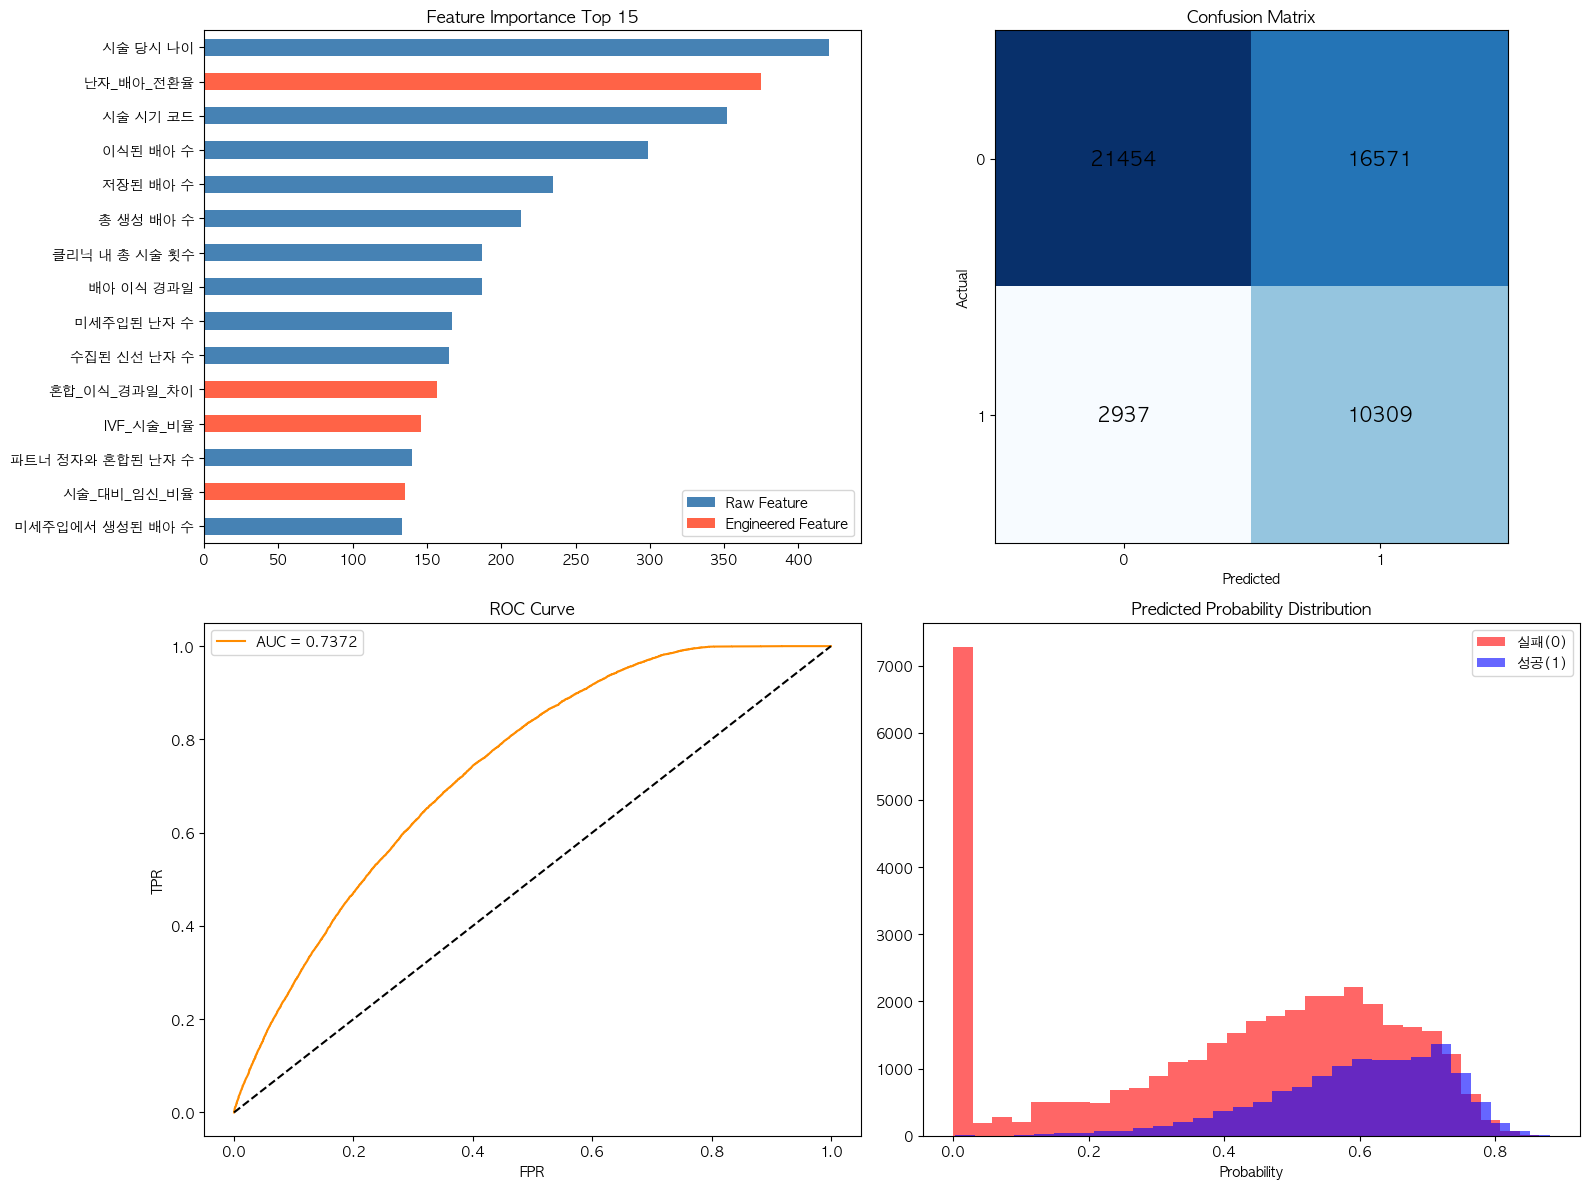

그래프 저장 완료: result_plots_exp020.png


In [16]:
# ════════════════════════════════════════════════════════════
# 시각화
# ════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve
from matplotlib.patches import Patch

engineered_features = [
    "IVF_DI_시술_합산", "IVF_시술_비율",
    "IVF_DI_임신_합산", "IVF_임신_비율",
    "IVF_DI_출산_합산", "IVF_출산_비율",
    "시술_대비_임신_비율", "불임_원인_개수", "배아_사용_조합",
    "임신시도_결측여부", "이전_임신_여부", "이전_출산_여부",
    "전체_임신_성공률", "난자_배아_전환율", "고령_여부", "첫_시술_여부",
    "난자 채취 경과일_결측여부", "난자 혼합 경과일_결측여부", "배아 이식 경과일_결측여부",
    # exp020 신규
    "배아_이식_경과일_구간", "조기_이식_여부",
    "채취_이식_경과일_차이", "혼합_이식_경과일_차이",
]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1) Feature Importance Top 15
top15  = feat_imp.nlargest(15)
colors = ['tomato' if f in engineered_features else 'steelblue' for f in top15.index]
top15.plot(kind='barh', ax=axes[0, 0], color=colors)
axes[0, 0].set_title('Feature Importance Top 15')
axes[0, 0].invert_yaxis()
axes[0, 0].legend(handles=[
    Patch(facecolor='steelblue', label='Raw Feature'),
    Patch(facecolor='tomato',    label='Engineered Feature'),
], loc='lower right')

# 2) Confusion Matrix
cm = confusion_matrix(y_val, val_pred)
axes[0, 1].imshow(cm, cmap='Blues')
axes[0, 1].set_title('Confusion Matrix')
for i in range(2):
    for j in range(2):
        axes[0, 1].text(j, i, cm[i, j], ha='center', va='center', fontsize=14)
axes[0, 1].set_xlabel('Predicted'); axes[0, 1].set_ylabel('Actual')
axes[0, 1].set_xticks([0, 1]);      axes[0, 1].set_yticks([0, 1])

# 3) ROC Curve
fpr, tpr, _ = roc_curve(y_val, val_proba)
axes[1, 0].plot(fpr, tpr, label=f'AUC = {val_auc:.4f}', color='darkorange')
axes[1, 0].plot([0, 1], [0, 1], 'k--')
axes[1, 0].set_title('ROC Curve')
axes[1, 0].set_xlabel('FPR'); axes[1, 0].set_ylabel('TPR')
axes[1, 0].legend()

# 4) 예측 확률 분포
axes[1, 1].hist(val_proba[y_val == 0], bins=30, alpha=0.6, label='실패(0)', color='red')
axes[1, 1].hist(val_proba[y_val == 1], bins=30, alpha=0.6, label='성공(1)', color='blue')
axes[1, 1].set_title('Predicted Probability Distribution')
axes[1, 1].set_xlabel('Probability'); axes[1, 1].legend()

plt.tight_layout()
plt.savefig('result_plots_exp020.png', dpi=150, bbox_inches='tight')
plt.show()
print("그래프 저장 완료: result_plots_exp020.png")

In [17]:
# ════════════════════════════════════════════════════════════
# catboost 확인
# ════════════════════════════════════════════════════════════

from catboost import CatBoostClassifier

# CatBoost 베이스라인
cat_params = {
    "iterations":        500,
    "learning_rate":     0.05,
    "depth":             6,
    "scale_pos_weight":  scale_pos_weight,
    "random_seed":       42,
    "verbose":           0,
    "eval_metric":       "AUC",
    "thread_count":      -1,
}

cat_model = CatBoostClassifier(**cat_params)
cat_model.fit(X_train, y_train)

cat_auc = roc_auc_score(y_val, cat_model.predict_proba(X_val)[:, 1])
print(f"CatBoost Val AUC: {cat_auc:.4f}")

val_pred  = cat_model.predict(X_val)
val_proba = cat_model.predict_proba(X_val)[:, 1]

print("\n[Classification Report]")
print(classification_report(y_val, val_pred))
print("\n[Confusion Matrix]")
print(confusion_matrix(y_val, val_pred))

feat_imp = pd.Series(cat_model.get_feature_importance(),
                        index=X_train.columns)
print("\n[Feature Importance Top 15]")
print(feat_imp.nlargest(15))


CatBoost Val AUC: 0.7372

[Classification Report]
              precision    recall  f1-score   support

           0       0.88      0.57      0.69     38025
           1       0.39      0.77      0.51     13246

    accuracy                           0.62     51271
   macro avg       0.63      0.67      0.60     51271
weighted avg       0.75      0.62      0.65     51271


[Confusion Matrix]
[[21668 16357]
 [ 2982 10264]]

[Feature Importance Top 15]
이식된 배아 수          45.572153
배아 이식 경과일_결측여부    11.552746
저장된 배아 수           5.296402
시술 당시 나이           4.837964
난자 채취 경과일_결측여부     3.620128
배아 생성 주요 이유        3.522782
수집된 신선 난자 수        3.225867
총 생성 배아 수          3.028739
배란 유도 유형           2.706321
고령_여부              1.501317
난자_배아_전환율          1.187731
난자 기증자 나이          0.757398
배아_사용_조합           0.745419
혼합_이식_경과일_차이       0.736573
시술 시기 코드           0.684042
dtype: float64


In [19]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
# ════════════════════════════════════════════════════════════
# Optuna 가중치 앙상블 (LGB + CAT + XGB)
# ════════════════════════════════════════════════════════════
from xgboost import XGBClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── XGB 학습 (아직 없으면) ──
xgb_params = {
    "n_estimators":     500,
    "learning_rate":    0.05,
    "max_depth":        6,
    "min_child_weight": 1,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "scale_pos_weight": scale_pos_weight,
    "random_state":     42,
    "n_jobs":           -1,
    "verbosity":        0,
    "eval_metric":      "auc",
}
xgb_model = XGBClassifier(**xgb_params)
xgb_model.fit(X_train, y_train)

# ── 각 모델 Val 확률 ──
lgb_proba = check_model.predict_proba(X_val)[:, 1]   # 위 셀에서 학습된 LGB
cat_proba = cat_model.predict_proba(X_val)[:, 1]     # 위 셀에서 학습된 CAT
xgb_proba = xgb_model.predict_proba(X_val)[:, 1]

lgb_auc = roc_auc_score(y_val, lgb_proba)
cat_auc = roc_auc_score(y_val, cat_proba)
xgb_auc = roc_auc_score(y_val, xgb_proba)

print(f"LGB Val AUC: {lgb_auc:.4f}")
print(f"CAT Val AUC: {cat_auc:.4f}")
print(f"XGB Val AUC: {xgb_auc:.4f}")


LGB Val AUC: 0.7372
CAT Val AUC: 0.7372
XGB Val AUC: 0.7352


In [20]:
# ── Optuna 가중치 최적화 ──
def objective(trial):
    w_lgb = trial.suggest_float("w_lgb", 0.0, 1.0)
    w_cat = trial.suggest_float("w_cat", 0.0, 1.0)
    w_xgb = trial.suggest_float("w_xgb", 0.0, 1.0)
    total = w_lgb + w_cat + w_xgb + 1e-8
    ensemble = (lgb_proba * w_lgb + cat_proba * w_cat + xgb_proba * w_xgb) / total
    return roc_auc_score(y_val, ensemble)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=200, show_progress_bar=True)

# ── 최적 가중치 정규화 ──
w = study.best_params
total = w["w_lgb"] + w["w_cat"] + w["w_xgb"]
w_lgb = w["w_lgb"] / total
w_cat = w["w_cat"] / total
w_xgb = w["w_xgb"] / total

print(f"\nBest Val AUC:  {study.best_value:.4f}")
print(f"최적 가중치 — LGB: {w_lgb:.3f} | CAT: {w_cat:.3f} | XGB: {w_xgb:.3f}")


  0%|          | 0/200 [00:00<?, ?it/s]


Best Val AUC:  0.7374
최적 가중치 — LGB: 0.527 | CAT: 0.459 | XGB: 0.013


In [21]:
# ── Val 최종 앙상블 성능 ──
ensemble_val = lgb_proba * w_lgb + cat_proba * w_cat + xgb_proba * w_xgb
ensemble_auc = roc_auc_score(y_val, ensemble_val)
ensemble_pred = (ensemble_val >= 0.5).astype(int)

print(f"\n[앙상블 Val AUC]: {ensemble_auc:.4f}")
print("\n[Classification Report]")
print(classification_report(y_val, ensemble_pred))
print("\n[Confusion Matrix]")
print(confusion_matrix(y_val, ensemble_pred))


[앙상블 Val AUC]: 0.7374

[Classification Report]
              precision    recall  f1-score   support

           0       0.88      0.57      0.69     38025
           1       0.39      0.78      0.52     13246

    accuracy                           0.62     51271
   macro avg       0.63      0.67      0.60     51271
weighted avg       0.75      0.62      0.64     51271


[Confusion Matrix]
[[21569 16456]
 [ 2943 10303]]


* 윤재님 파일 다운받아서 그대로 재현했을때 [앙상블 Val AUC]: 0.7374 (LB 점수: 0.7412775224) 확보됨 
이것을 베이스라인으로 할 것임

1. 검증 방법:
train_test_split (test_size=0.2, stratify=y)

2. 사용 피처 수:
X_train.shape[1] (85개)

3. threshold:
0.5 (기본값, 튜닝 없음)